In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/1730285881-Airbnb_Open_Data.csv", engine='python')
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,19-10-2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,21-05-2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,05-07-2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,19-11-2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [6]:
print("Shape of the Dataset:",df.shape)

Shape of the Dataset: (102599, 26)


In [7]:
print("No.of Rows in the Dataset:",df.shape[0])

No.of Rows in the Dataset: 102599


In [8]:
print("Statistics about Numerical Columns of the Dataset:\n",df.describe())

Statistics about Numerical Columns of the Dataset:
                  id       host id            lat           long  \
count  1.025990e+05  1.025990e+05  102591.000000  102591.000000   
mean   2.914623e+07  4.925411e+10      40.728094     -73.949644   
std    1.625751e+07  2.853900e+10       0.055857       0.049521   
min    1.001254e+06  1.236005e+08      40.499790     -74.249840   
25%    1.508581e+07  2.458333e+10      40.688740     -73.982580   
50%    2.913660e+07  4.911774e+10      40.722290     -73.954440   
75%    4.320120e+07  7.399650e+10      40.762760     -73.932350   
max    5.736742e+07  9.876313e+10      40.916970     -73.705220   

       Construction year  minimum nights  number of reviews  \
count      102385.000000   102190.000000      102416.000000   
mean         2012.487464        8.135845          27.483743   
std             5.765556       30.553781          49.508954   
min          2003.000000    -1223.000000           0.000000   
25%          2007.000000     

In [9]:
print("Column Wise Information")
df.info()

Column Wise Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  objec

In [10]:
df.dtypes

,0
id,int64
NAME,object
host id,int64
host_identity_verified,object
host name,object
neighbourhood group,object
neighbourhood,object
lat,float64
long,float64
country,object


In [11]:
df.isnull().sum()

,0
id,0
NAME,250
host id,0
host_identity_verified,289
host name,406
neighbourhood group,29
neighbourhood,16
lat,8
long,8
country,532


In [12]:
print("No.of Nulls present in the dataset:",df.isnull().sum().sum())

No.of Nulls present in the dataset: 190769


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'host id'}>,
        <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'Construction year'}>,
        <Axes: title={'center': 'minimum nights'}>],
       [<Axes: title={'center': 'number of reviews'}>,
        <Axes: title={'center': 'reviews per month'}>,
        <Axes: title={'center': 'review rate number'}>],
       [<Axes: title={'center': 'calculated host listings count'}>,
        <Axes: title={'center': 'availability 365'}>, <Axes: >]],
      dtype=object)

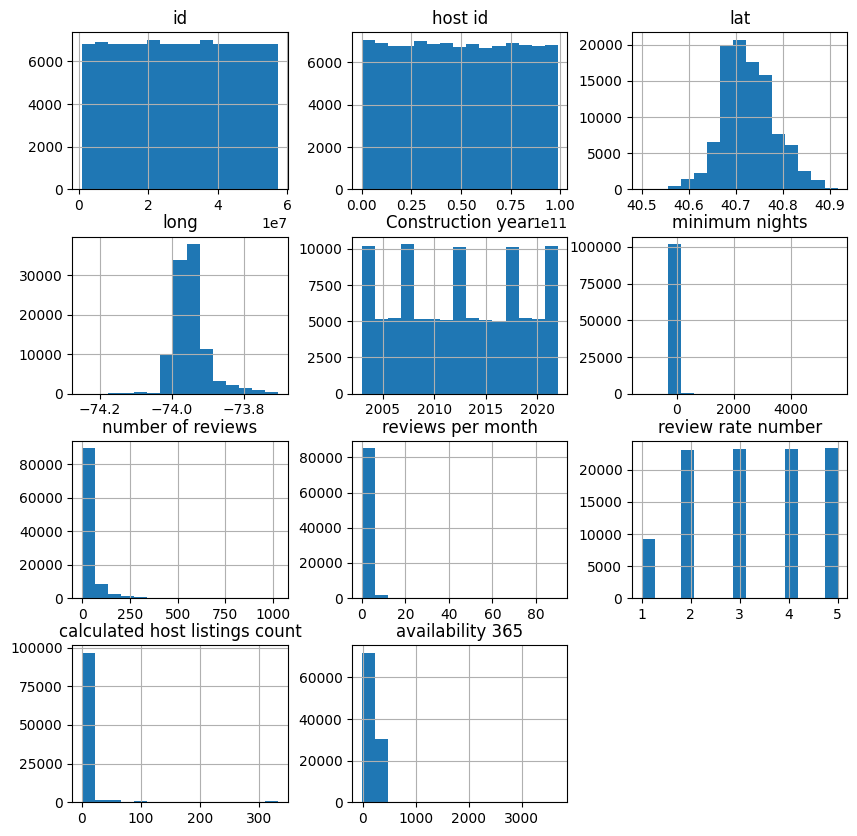

In [13]:
df.hist(bins=15,figsize=(10,10))

<Axes: ylabel='neighbourhood group'>

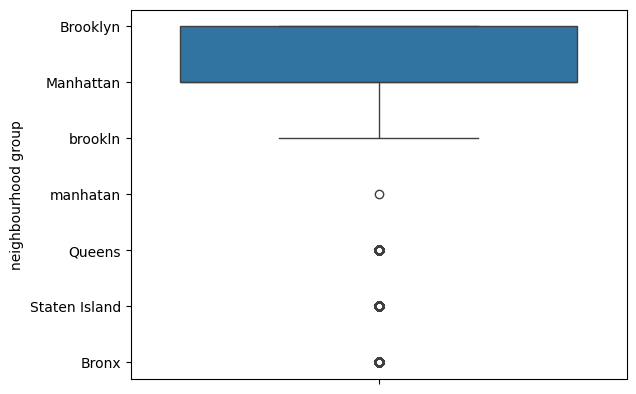

In [16]:
sns.boxplot(y='neighbourhood group',data=df)

In [23]:
file_path = '/content/1730285881-Airbnb_Open_Data.csv'
df = pd.read_csv(file_path, engine='python')

df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
if 'last_review' in df.columns:
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Clean 'price' and 'service_fee' columns before converting to numeric
if 'price' in df.columns:
    df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
if 'service_fee' in df.columns:
    df['service_fee'] = df['service_fee'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

num_cols = ['lat','long','price','service_fee','minimum_nights','number_of_reviews','reviews_per_month','review_rate_number','calculated_host_listings_count','availability_365','construction_year']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print(df.head())
print('Data loaded and cleaned')

/tmp/ipython-input-2044059529.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')


        id                                              name      host_id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host_name neighbourhood_group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service_fee minimum_nights  \
0  40.64749 -73.97237  United St

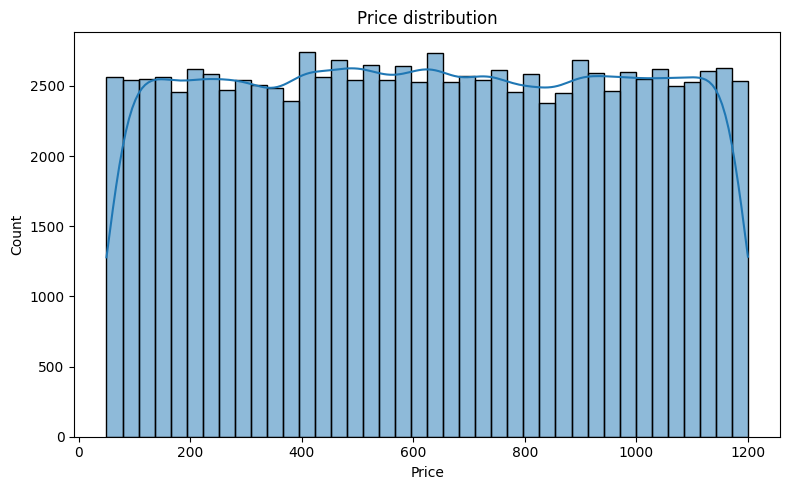

Plotted price distribution


In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'].dropna(), bins=40, kde=True)
plt.title('Price distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Plotted price distribution')

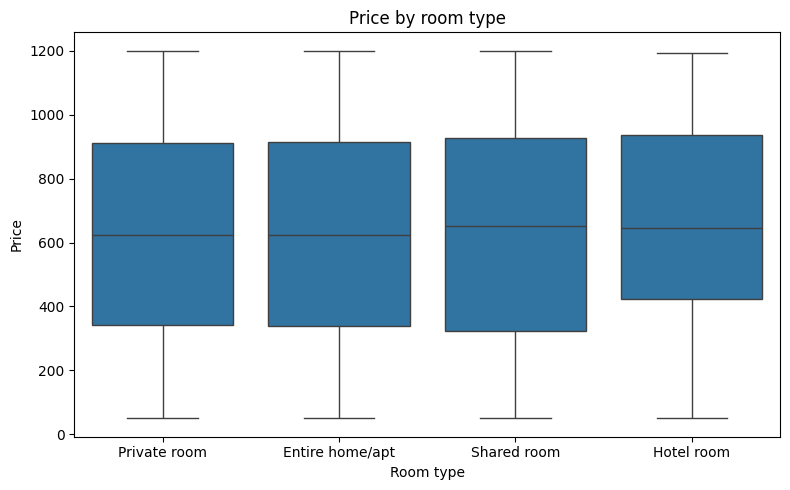

Plotted price by room type


In [24]:
if 'room_type' in df.columns and 'price' in df.columns:
    # Drop rows with missing values in 'room_type' or 'price'
    df_cleaned = df.dropna(subset=['room_type', 'price'])

    plt.figure(figsize=(8,5))
    sns.boxplot(data=df_cleaned, x='room_type', y='price')
    plt.title('Price by room type')
    plt.xlabel('Room type')
    plt.ylabel('Price')
    plt.tight_layout()
    plt.show()
else:
    print("Required columns ('room_type' or 'price') not found in the DataFrame.")

print('Plotted price by room type')

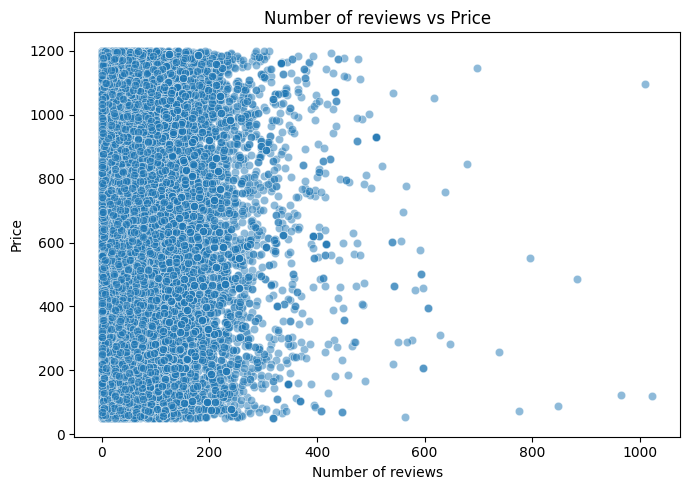

Plotted reviews vs price


In [26]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='number_of_reviews', y='price', alpha=0.5)
plt.title('Number of reviews vs Price')
plt.xlabel('Number of reviews')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

print('Plotted reviews vs price')

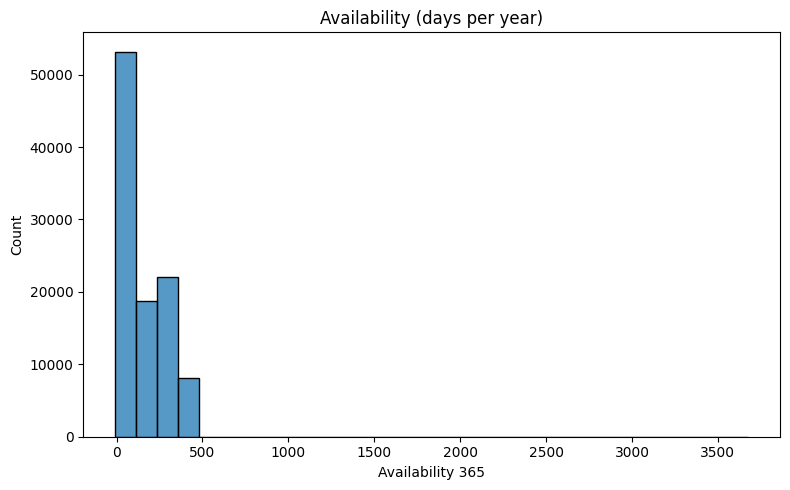

Plotted availability distribution


In [27]:
if 'availability_365' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['availability_365'].dropna(), bins=30)
    plt.title('Availability (days per year)')
    plt.xlabel('Availability 365')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

print('Plotted availability distribution')

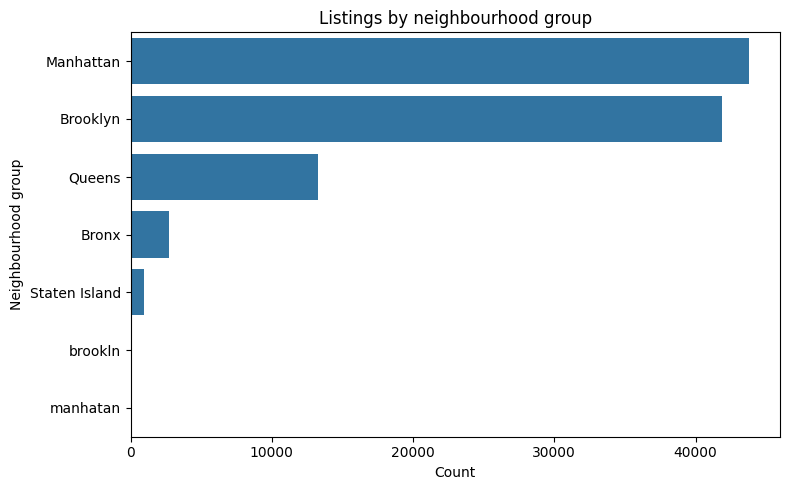

Plotted listing counts by neighbourhood group


In [28]:
if 'neighbourhood_group' in df.columns:
    plt.figure(figsize=(8,5))
    top_ng = df['neighbourhood_group'].value_counts().head(15)
    sns.barplot(x=top_ng.values, y=top_ng.index)
    plt.title('Listings by neighbourhood group')
    plt.xlabel('Count')
    plt.ylabel('Neighbourhood group')
    plt.tight_layout()
    plt.show()

print('Plotted listing counts by neighbourhood group')

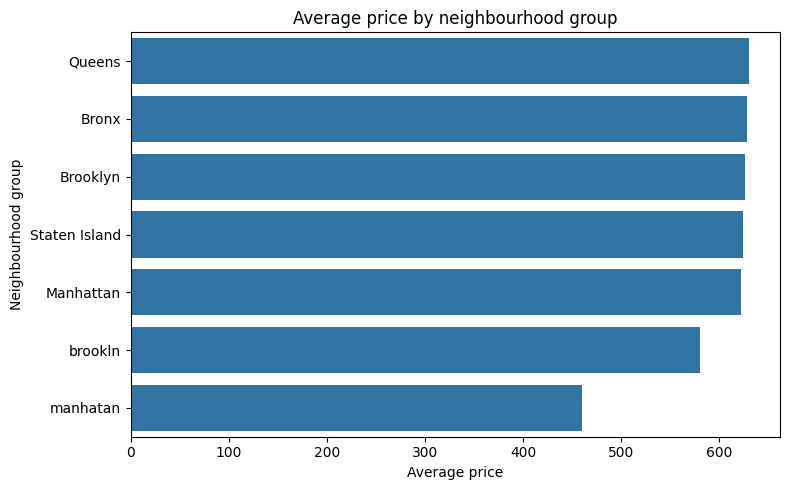

Plotted average price by neighbourhood group


In [29]:
if 'neighbourhood_group' in df.columns:
    gp = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False).head(20)
    plt.figure(figsize=(8,5))
    sns.barplot(x=gp.values, y=gp.index)
    plt.title('Average price by neighbourhood group')
    plt.xlabel('Average price')
    plt.ylabel('Neighbourhood group')
    plt.tight_layout()
    plt.show()

print('Plotted average price by neighbourhood group')

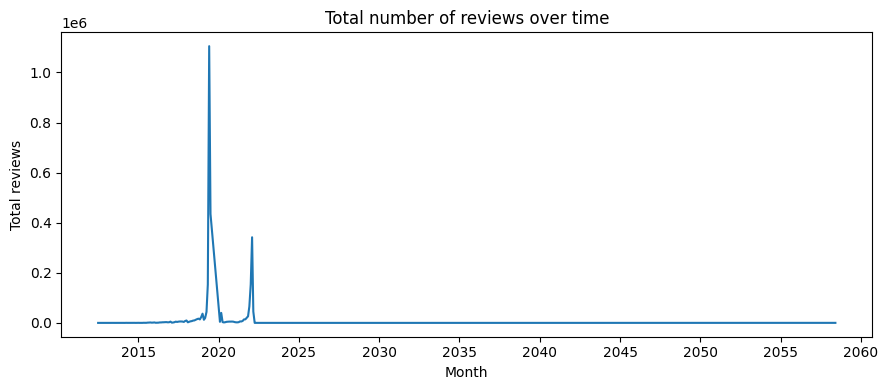

Plotted monthly total reviews trend


In [30]:
if 'last_review' in df.columns and df['last_review'].notna().any():
    tmp = df.dropna(subset=['last_review']).copy()
    tmp['year_month'] = tmp['last_review'].dt.to_period('M').dt.to_timestamp()
    monthly = tmp.groupby('year_month')['number_of_reviews'].sum().reset_index()
    monthly = monthly.sort_values('year_month')

    plt.figure(figsize=(9,4))
    sns.lineplot(data=monthly, x='year_month', y='number_of_reviews')
    plt.title('Total number of reviews over time')
    plt.xlabel('Month')
    plt.ylabel('Total reviews')
    plt.tight_layout()
    plt.show()

print('Plotted monthly total reviews trend')

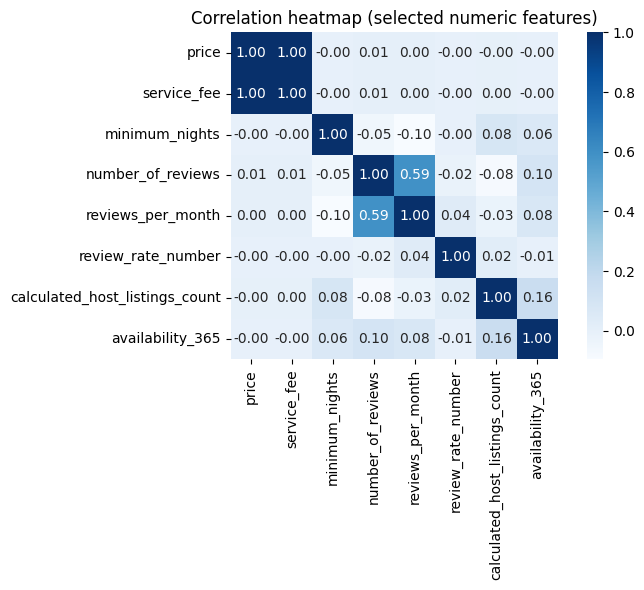

Plotted correlation heatmap


In [31]:
cols = ['price','service_fee','minimum_nights','number_of_reviews','reviews_per_month','review_rate_number','calculated_host_listings_count','availability_365']
present = [c for c in cols if c in df.columns]
corr = df[present].corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', square=True)
plt.title('Correlation heatmap (selected numeric features)')
plt.tight_layout()
plt.show()

print('Plotted correlation heatmap')

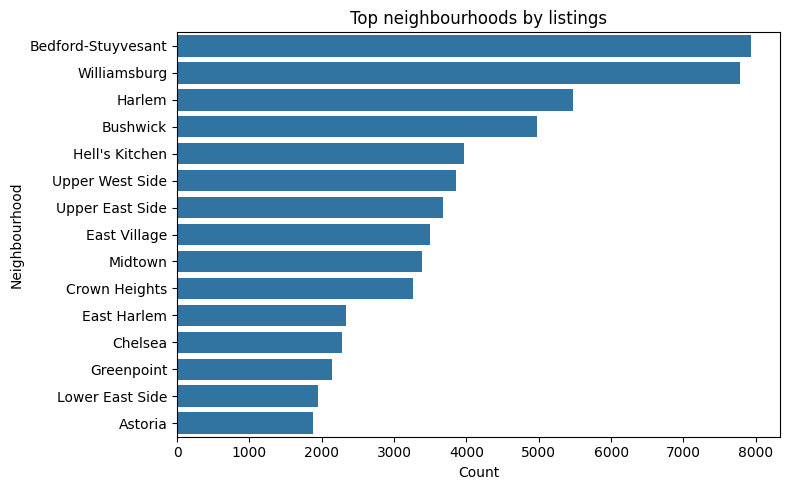

Plotted top neighbourhoods by listings


In [32]:
if 'neighbourhood' in df.columns:
    neigh_ct = df['neighbourhood'].value_counts().head(15)
    plt.figure(figsize=(8,5))
    sns.barplot(x=neigh_ct.values, y=neigh_ct.index)
    plt.title('Top neighbourhoods by listings')
    plt.xlabel('Count')
    plt.ylabel('Neighbourhood')
    plt.tight_layout()
    plt.show()

print('Plotted top neighbourhoods by listings')

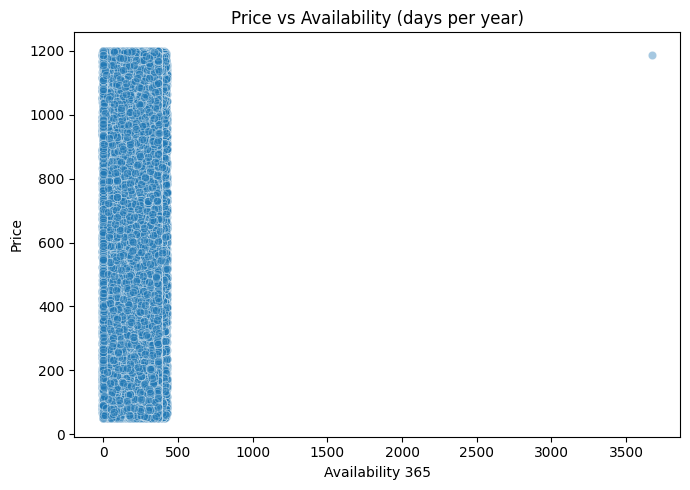

Plotted price vs availability


In [33]:
if 'availability_365' in df.columns:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df, x='availability_365', y='price', alpha=0.4)
    plt.title('Price vs Availability (days per year)')
    plt.xlabel('Availability 365')
    plt.ylabel('Price')
    plt.tight_layout()
    plt.show()

print('Plotted price vs availability')

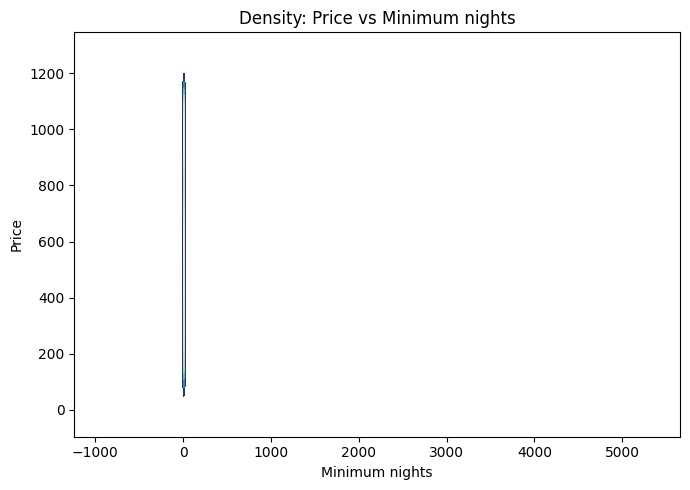

Plotted density of price vs minimum nights


In [37]:
if 'minimum_nights' in df.columns:
    plt.figure(figsize=(7,5))
    sns.kdeplot(
        data=df.dropna(subset=['price','minimum_nights']),
        x='minimum_nights', y='price', fill=True, thresh=0.05, levels=30, cmap='mako'
    )
    plt.title('Density: Price vs Minimum nights')
    plt.xlabel('Minimum nights')
    plt.ylabel('Price')
    plt.tight_layout()
    plt.show()

print('Plotted density of price vs minimum nights')

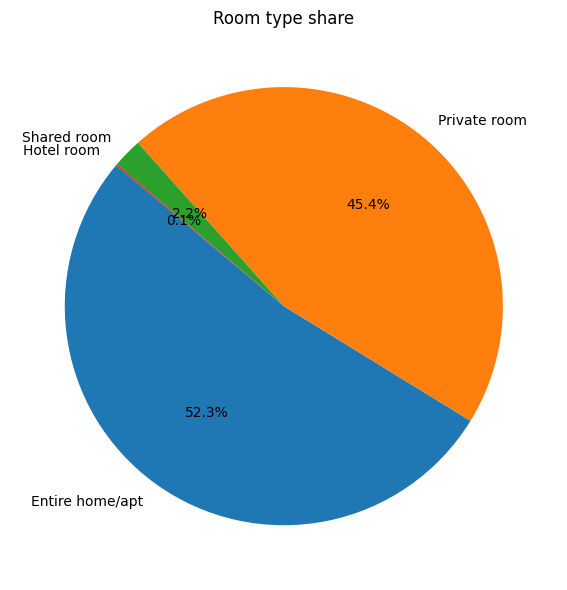

Plotted room type share


In [36]:
if 'room_type' in df.columns:
    shares = df['room_type'].value_counts()
    plt.figure(figsize=(6,6))
    plt.pie(shares.values, labels=shares.index, autopct='%1.1f%%', startangle=140)
    plt.title('Room type share')
    plt.tight_layout()
    plt.show()

print('Plotted room type share')

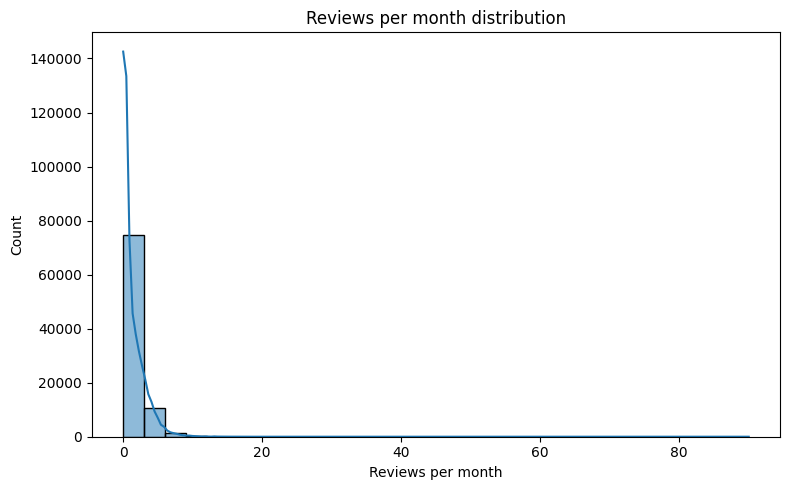

Plotted reviews per month distribution


In [38]:
if 'reviews_per_month' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['reviews_per_month'].dropna(), bins=30, kde=True)
    plt.title('Reviews per month distribution')
    plt.xlabel('Reviews per month')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

print('Plotted reviews per month distribution')

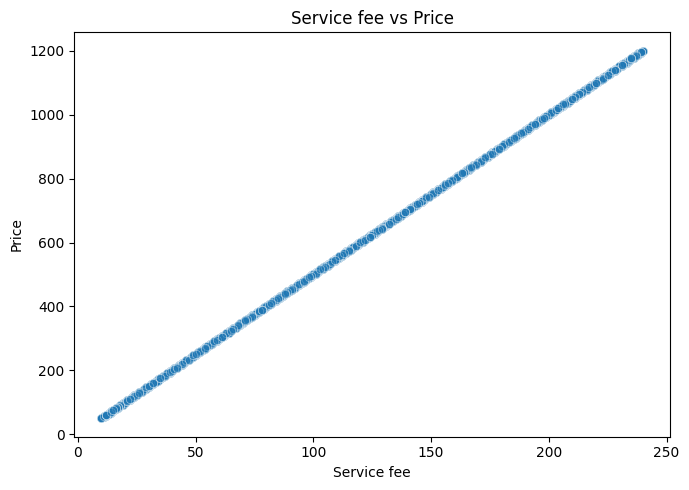

Plotted service fee vs price


In [39]:
if 'service_fee' in df.columns:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df, x='service_fee', y='price', alpha=0.5)
    plt.title('Service fee vs Price')
    plt.xlabel('Service fee')
    plt.ylabel('Price')
    plt.tight_layout()
    plt.show()

print('Plotted service fee vs price')

  neighbourhood_group        room_type  review_rate_number
0               Bronx  Entire home/apt            3.346457
1               Bronx     Private room            3.329706
2               Bronx      Shared room            3.264957
3            Brooklyn  Entire home/apt            3.250378
4            Brooklyn       Hotel room            3.750000


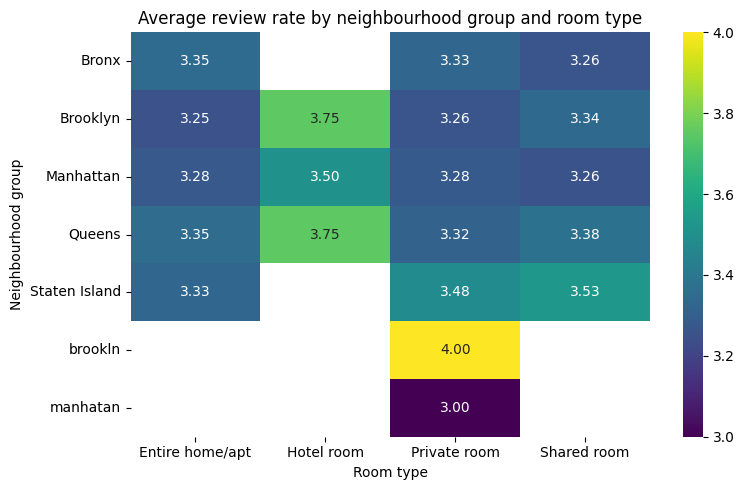

Computed and plotted average review rate by group and room type


In [40]:
needed = ['neighbourhood_group', 'room_type', 'review_rate_number']
for col in needed:
    if col not in df.columns:
        raise KeyError('Missing column: ' + col)

# Group and compute mean
pivot = df.groupby(['neighbourhood_group','room_type'])['review_rate_number'].mean().reset_index()
heat = pivot.pivot(index='neighbourhood_group', columns='room_type', values='review_rate_number')

print(pivot.head())

plt.figure(figsize=(8,5))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='viridis')
plt.title('Average review rate by neighbourhood group and room type')
plt.xlabel('Room type')
plt.ylabel('Neighbourhood group')
plt.tight_layout()
plt.show()

print('Computed and plotted average review rate by group and room type')